# Smart Farming (ThingSpeak Channel 80502): Models/AIntl Evaluation

**Branch:** `kim/report/farming` (experiment only, not merged into `main`)  
**Location:** `data_science/datasets/farming/`

This notebook is a single reproducible run: **Task 1** (dataset selection, field identification, timestamp/quality checks, correlation suitability, carried over unchanged from the standalone Task 1 analysis, with only the data path made relative) followed by **Task 2** (EDA recap, preprocessing, Models/AIntl execution, evaluation, visualisations, interpretation, limitations, conclusions).

---

# Task 1: Dataset Selection and Relevance

# 1 Real-World Dataset Selection and MVP Relevance

## 1.1 Dataset Selection and Relevance

### 1.1.1 Dataset

- **Dataset:** ThingSpeak public channel **80502**, greenhouse 
- **Selected file:** `data/farming.csv`
- **Domain:** IoT / agricultural environmental monitoring

### 1.1.2 What the dataset represents

Climate readings from a sensor inside a greenhouse, logged roughly once a minute.
The device measures four things directly: air temperature, a second temperature from another probe, relative humidity, and CO2. It then calculates four more from the first two including wet bulb temperature, absolute humidity, dew point, and humidity deficit, then reports all eight together.
That set is what a standard greenhouse climate computer produces. Growers make decisions on dew point and humidity deficit rather than on raw humidity, because those are the numbers that tell you whether plants can transpire and whether water will condense on the leaves.

### 1.1.3 Dataset source and provenance

- **Source:** ThingSpeak public channel 80502 (MathWorks ThingSpeak IoT platform)
- **Channel page:** `https://thingspeak.com/channels/80502`
- **Retrieval endpoint:** `https://api.thingspeak.com/channels/80502/feeds.csv?results=8000`
- **Retrieved:** `<date>`
- **Access:** public channel, no API key required
- **Coverage:** 27 June 2019 to 12 October 2019 (in three disjoint blocks; see Section 3.1)

> **Field names.** The ThingSpeak CSV export writes only `field1` through `field8`; the
> human-readable labels live in the channel metadata returned by the JSON
> endpoint. The mapping used in this notebook was **derived from the data
> itself** and verified numerically in Section 2.2, not assumed. Confirm against
> `https://api.thingspeak.com/channels/80502/feeds.json?results=1` and correct
> if the channel owner's labels differ.

### 1.1.4 Why I selected this dataset

Agriculture was chosen because no other team member is using it and compared to other internet dataset, thingspeak give more detail and right field to test. Moreover, temperature and humidity are physically linked. Warm air holds more moisture, so relative humidity falls as temperature rises. This happens every day, driven by physics rather than coincidence. If the two streams stop moving in opposite directions, something has failed like a jammed vent, a heater fault, a drifting sensor and this can occur while both readings still look normal individually. That gives the Correlation module a relationship with a known expected sign to test against.
It matches the production ingestion path. The backend already ingests from ThingSpeak and expects created_at, entry_id and fieldN columns, which is exactly what this file contains. Testing against a real ThingSpeak channel validates the same data shape the system will receive in production.
It has real data-quality defects. This is a live deployment, not a curated benchmark. It contains two multi-week outages, a block where the device reported error codes instead of readings, and a CO2 channel that sticks at its minimum value. These are the conditions the MVP will actually meet.

### 1.1.5 Main variables

| Field | Name used here | Kind | Meaning |
|---|---|---|---|
| field1 | `temp_c` | **measured** | Air temperature, (22.3-29.1) °C |
| field2 | `wet_bulb_c` | derived | The coldest that could change liquid to vapour, (15.5-24.2) °C |
| field3 | `temp2_c` | **measured** | Second temperature somewhere else, (20.6-26.1) °C (location unconfirmed) |
| field4 | `humidity_pct` | **measured** | Relative humidity how full the air is with water, (32.2-64.6) % |
| field5 | `abs_humidity_gm3` | derived | The actual water in the air, (8.3-19.8) g/m³ |
| field6 | `dew_point_c` | derived | Temperature when gas or vapour turn to liquid, (9.0-22.6) °C |
| field7 | `humidity_deficit_gm3` | derived | how much more water the air could still absorb, (6.6-18.2) g/m³ |
| field8 | `co2_ppm` | **measured** | CO2 in air, (400-871) ppm |

Plus `created_at` (UTC timestamp) and `entry_id` (monotonic sequence number).

Important for the correlation configuration: fields 2, 5, 6 and 7 are
deterministic functions of fields 1 and 4, this is verified numerically in
Section 2.2. Correlating `temp_c` against any of them would measure the psychrometric
formula rather than a physical relationship between independent sensors, and
would return a spuriously near-perfect coefficient. Only `temp_c`, `temp2_c`,
`humidity_pct` and `co2_ppm` are independent measurements, and correlation
streams are drawn only from those.

### 1.1.6 Timestamp availability

`created_at` is a single ISO-style UTC timestamp per record, so no field
combination is required (unlike the TON_IoT weather dataset, which stores date
and time separately). Cadence, ordering, duplicates and gaps are examined in
Section 3.1.

### 1.1.7 Potential anomaly detection

Six kinds of unusual behaviour this dataset could realistically contain:

- **Sensor faults**, The device stops sending readings and sends error codes instead. This file has one: a block of 22 rows where every field reads 99.9 or 9999. Those aren't measurements, they mean the sensor knew something was wrong.
- **Sudden jumps**, Temperature or CO2 shifting sharply in a short time, which would suggest a heater, vent, or CO2 system failing.
- **Stuck readings**, One sensor frozen on the same number while the others keep changing. The CO2 sensor floors at its 400 ppm minimum, which is the outdoor baseline rather than a measured indoor value.
- **Broken day/night pattern**, Greenhouse temperature normally follows a daily rhythm, warm in the day, cooler at night. If that pattern disappears, the climate control has probably failed.
- **Data going missing**, The device drops offline and sends nothing. This file has two outages, 47 days and 55 days. The system needs to treat these as "no data" rather than "the value was zero."
- **Temperature and humidity coming apart**, These two normally move in opposite directions. If they stop doing that, something has failed.


### 1.1.8 Potential correlation analysis

temp_c and humidity_pct come from two separate sensors, and physics forces them to move in opposite directions: as air warms it can hold more water, so relative humidity falls.
The Correlation module doesn't measure this once across the whole dataset. It uses a rolling window of 20 readings, stepping forward 10 at a time, so it produces a fresh correlation value every few minutes.
That distinction matters. A single number for the whole file would just tell us the relationship exists. What we actually want is to watch that number over time. Most of the time it should sit at roughly the same negative value. When it drifts away from that, something has changed in how the two sensors relate and that's the anomaly.

co2_ppm against temp_c is a possible second pairing, though weaker. In a greenhouse where CO2 is being added deliberately, dosing happens during daylight, which is also when temperature rises. so, the two would tend to climb together. If that daytime link were missing, it would point to a dosing failure. One caveat: the CO2 readings in this file sit at the 400 ppm outdoor baseline, which suggests this greenhouse wasn't being enriched, so the association may not appear at all.

### 1.1.9 Relevance to the IoT Analytics MVP

So far the MVP has only been tested on NAB. If it works on this dataset too, that's evidence the system is a general IoT analytics tool rather than something tuned to one benchmark.
Greenhouse data is a good second test because it differs from NAB in three specific ways:

1. **It has a strong daily rhythm.** NAB series mostly don't repeat on a schedule. Greenhouse temperature does, warm during the day and cooler at night, every day. That's a real test of the detector: it has to learn that the daily swing is normal. If Isolation Forest flags every afternoon as an anomaly, we've found a genuine weakness.
2. **Two sensors are physically linked.** Temperature and humidity don't just happen to correlate here, one causes the other to change. So we know in advance that the correlation should be negative, and we can check whether the module finds what physics says it should.
3. **It's the format the system will actually receive.** The backend ingests from ThingSpeak, and this file came straight from ThingSpeak. No conversion, no substitute format.

---

## 1.2 Dataset Access and Loading

The dataset has been obtained locally. The cells below load the CSV, apply the
field mapping, and perform a light initial inspection to confirm it contains
the time-series and numerical information required for further analysis.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

DATA_PATH     = Path("data/farming.csv")   # ThingSpeak channel 80502 (copied in from Task 1)
TIMESTAMP_COL = "created_at"

# Field mapping. See section 2.2 for the numerical verification that
# fields 2, 5, 6 and 7 are DERIVED from fields 1 and 4.
RENAMES = {
    "field1": "temp_c",                 # measured  - air temperature (dry bulb)
    "field2": "wet_bulb_c",             # DERIVED   - from temp + RH
    "field3": "temp2_c",                # measured  - second temperature probe
    "field4": "humidity_pct",           # measured  - relative humidity
    "field5": "abs_humidity_gm3",       # DERIVED   - absolute humidity
    "field6": "dew_point_c",            # DERIVED   - dew point
    "field7": "humidity_deficit_gm3",   # DERIVED   - saturation deficit
    "field8": "co2_ppm",                # measured  - 400 floor, 9999 = fault
}

# Only these four are independent sensors; the rest are computed from them.
INDEPENDENT = ["temp_c", "temp2_c", "humidity_pct", "co2_ppm"]
DERIVED     = ["wet_bulb_c", "abs_humidity_gm3", "dew_point_c",
               "humidity_deficit_gm3"]

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.rename(columns=RENAMES)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully.
Dataset shape: (7488, 10)


,created_at,entry_id,temp_c,wet_bulb_c,temp2_c,humidity_pct,abs_humidity_gm3,dew_point_c,humidity_deficit_gm3,co2_ppm
0,2019-06-27 09:19:53 UTC,1,28.3,24.2,27.5,70.8,19.7,22.5,8.1,514.72736
1,2019-06-27 09:20:56 UTC,2,28.3,24.2,27.5,70.7,19.7,22.5,8.2,514.59082
2,2019-06-27 09:21:58 UTC,3,28.3,24.2,27.5,70.8,19.7,22.5,8.1,514.02637
3,2019-06-27 09:22:57 UTC,4,28.3,24.2,27.6,70.7,19.7,22.5,8.2,513.78888
4,2019-06-27 09:24:57 UTC,5,28.3,24.1,27.6,70.7,19.7,22.5,8.1,512.72650


### 1.3 Initial dataset structure

Column names and data types are inspected to confirm the available timestamp,
sensor and identifier fields.

In [2]:
print("Raw column names (as exported by ThingSpeak):")
print(df_raw.columns.tolist())
print()
print("Mapped column names:")
print(df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Raw column names (as exported by ThingSpeak):
['created_at', 'entry_id', 'field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8']

Mapped column names:
['created_at', 'entry_id', 'temp_c', 'wet_bulb_c', 'temp2_c', 'humidity_pct', 'abs_humidity_gm3', 'dew_point_c', 'humidity_deficit_gm3', 'co2_ppm']

Data types:
created_at                  str
entry_id                  int64
temp_c                  float64
wet_bulb_c              float64
temp2_c                 float64
humidity_pct            float64
abs_humidity_gm3        float64
dew_point_c             float64
humidity_deficit_gm3    float64
co2_ppm                 float64
dtype: object


---

## 2 Field Identification

## 2.1 Why this step is needed

ThingSpeak exports its columns as field1 through field8. It doesn't include the names the channel owner gave them, so the file arrives with no indication of what any column actually contains. The team also said testing guide also notes that proper names are preferred over raw fieldN for integration. Without knowing what each field is, there's no way to tell which columns are real sensor readings and which are calculated from other columns. That matters directly, because correlating a calculated column against the column it was calculated from would produce a meaningless result.
So the fields have to be identified before any analysis can be trusted.

## 2.2 Verifying the derived fields

Rather than assume the mapping, it is tested. If `wet_bulb_c`,
`abs_humidity_gm3`, `dew_point_c` and `humidity_deficit_gm3` are the standard
psychrometric quantities which is the study of moist air, they should be determined from `temp_c` and
`humidity_pct` alone using exist formulas.

In [3]:
import math

def sat_vapour_kpa(T):
    """Saturation vapour pressure (kPa), Tetens equation."""
    return 0.6108 * math.exp(17.27 * T / (T + 237.3))

def absolute_humidity(T, rh):
    """Absolute humidity, g/m3."""
    return 216.7 * (sat_vapour_kpa(T) * 10 * rh / 100) / (T + 273.15)

def dew_point(T, rh):
    """Dew point, degrees C (Magnus approximation)."""
    a = (17.27 * T) / (237.3 + T) + math.log(rh / 100)
    return 237.3 * a / (17.27 - a)

def wet_bulb(T, rh):
    """Wet bulb temperature, degrees C (Stull 2011 approximation)."""
    return (T * math.atan(0.151977 * (rh + 8.313659) ** 0.5)
            + math.atan(T + rh) - math.atan(rh - 1.676331)
            + 0.00391838 * rh ** 1.5 * math.atan(0.023101 * rh)
            - 4.686035)

def humidity_deficit(T, rh):
    """Saturation deficit, g/m3."""
    return absolute_humidity(T, 100) - absolute_humidity(T, rh)

FAULT_SENTINELS = {99.9, 455.0, 9999.0, 0.0}
clean = df[~df[["temp_c", "humidity_pct", "co2_ppm"]]
           .isin(FAULT_SENTINELS).any(axis=1)]
sample = clean.dropna(subset=["temp_c", "humidity_pct"]).sample(200, random_state=0)


checks = {
    "wet_bulb_c":           wet_bulb,
    "abs_humidity_gm3":     absolute_humidity,
    "dew_point_c":          dew_point,
    "humidity_deficit_gm3": humidity_deficit,
}

print(f"{'field':>22} {'max abs error':>15} {'mean abs error':>16}")
print("-" * 56)
for col, fn in checks.items():
    pred = sample.apply(
        lambda r: fn(r["temp_c"], r["humidity_pct"]), axis=1)
    err = (pred - sample[col]).abs()
    print(f"{col:>22} {err.max():15.3f} {err.mean():16.3f}")

print()
print("Errors are at or near the 0.1 rounding resolution of the source data,")
print("confirming these four fields are computed rather than independently")
print("sensed. wet_bulb_c shows a slightly larger residual because the Stull")
print("(2011) formula is an approximation of the psychrometric relation.")

                 field   max abs error   mean abs error
--------------------------------------------------------
            wet_bulb_c           0.153            0.054
      abs_humidity_gm3           0.177            0.044
           dew_point_c           0.105            0.031
  humidity_deficit_gm3           0.166            0.049

Errors are at or near the 0.1 rounding resolution of the source data,
confirming these four fields are computed rather than independently
sensed. wet_bulb_c shows a slightly larger residual because the Stull
(2011) formula is an approximation of the psychrometric relation.


The four fields reproduce to within the rounding
resolution of the source data. They are therefore *not* independent
measurements, and must be excluded from correlation analysis: pairing
`temp_c` with `dew_point_c` would return a coefficient close to 1.0 that
reflects the formula above rather than any physical relationship between
sensors.

This is the reason `SENSOR_COLS` below is restricted to the four independent
channels.

In [4]:
SENSOR_COLS = INDEPENDENT
print("Independent sensor channels used for analysis:")
for c in SENSOR_COLS:
    print(" -", c)
print()
print("Excluded as derived:")
for c in DERIVED:
    print(" -", c)

Independent sensor channels used for analysis:
 - temp_c
 - temp2_c
 - humidity_pct
 - co2_ppm

Excluded as derived:
 - wet_bulb_c
 - abs_humidity_gm3
 - dew_point_c
 - humidity_deficit_gm3


---

## 3 Timestamp Availability and Quality

The system pipeline requires one real timestamp column, and `timestamp_col`
must match the header exactly. ThingSpeak supplies `created_at` in UTC.

In [5]:
df["timestamp"] = pd.to_datetime(df[TIMESTAMP_COL], format="mixed",
                                 errors="coerce", utc=True)

print("Valid timestamps:  ", df["timestamp"].notna().sum())
print("Invalid timestamps:", df["timestamp"].isna().sum())
print()
print("Range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("Span: ", df["timestamp"].max() - df["timestamp"].min())
print()
df[[TIMESTAMP_COL, "timestamp", "entry_id"]].head()

Valid timestamps:  

 7488
Invalid timestamps: 0



Range: 2019-06-27 09:19:53+00:00 -> 2019-10-12 09:39:19+00:00


Span: 

 107 days 00:19:26



,created_at,timestamp,entry_id
0,2019-06-27 09:19:53 UTC,2019-06-27 09:19:53+00:00,1
1,2019-06-27 09:20:56 UTC,2019-06-27 09:20:56+00:00,2
2,2019-06-27 09:21:58 UTC,2019-06-27 09:21:58+00:00,3
3,2019-06-27 09:22:57 UTC,2019-06-27 09:22:57+00:00,4
4,2019-06-27 09:24:57 UTC,2019-06-27 09:24:57+00:00,5


### 3.1 Sampling flow, ordering, duplicates and gaps

A timestamp column existing is not the
same as it being usable as a time series. Three properties the Correlation
module depends on:

- **Cadence**, rolling correlation with `window_size=20` assumes roughly even
  spacing. Irregular intervals mean a window covers an inconsistent amount of
  real time.
- **Duplicates and ordering**, repeated or out-of-order timestamps distort a
  rolling window.
- **Gaps**, outages are the device being offline, not a real value of zero.

In [6]:
ts = df["timestamp"].dropna().sort_values()
deltas = ts.diff().dropna()

print("Monotonic increasing:", df["timestamp"].is_monotonic_increasing)
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
print("Duplicate entry_ids: ", df["entry_id"].duplicated().sum())
print()
print("Most common intervals:")
print(deltas.value_counts().head(5))

median = deltas.median()
print()
print("Median interval:", median)

gaps = deltas[deltas > median * 10]
print(f"Gaps greater than 10x median: {len(gaps)}")
for i in gaps.sort_values(ascending=False).head(5).index:
    prev = ts.loc[:i].iloc[-2]
    print(f"   {prev}  ->  {ts.loc[i]}   ({ts.loc[i] - prev})")

Monotonic increasing: True
Duplicate timestamps: 0
Duplicate entry_ids:  0

Most common intervals:
timestamp
0 days 00:01:00    6292
0 days 00:01:01     505
0 days 00:00:59     453
0 days 00:01:02     107
0 days 00:01:03      67
Name: count, dtype: int64

Median interval: 0 days 00:01:00
Gaps greater than 10x median: 4
   2019-08-13 15:20:56+00:00  ->  2019-10-07 08:26:11+00:00   (54 days 17:05:15)
   2019-06-27 14:09:02+00:00  ->  2019-08-13 14:59:32+00:00   (47 days 00:50:30)
   2019-06-27 11:26:55+00:00  ->  2019-06-27 11:40:18+00:00   (0 days 00:13:23)
   2019-06-27 10:38:04+00:00  ->  2019-06-27 10:51:04+00:00   (0 days 00:13:00)


### 3.2 Block selection and fault removal

Four decisions that must be made
explicitly and recorded, because each changes what the detector sees:

1. **Which block to use.** The data splits into three periods separated by
   multi-week outages. Treating them as one continuous series would place
   enormous artificial gaps inside rolling windows. The final continuous block
   is used as the primary series.
2. **Sensor error sentinels.** One short block reports fixed error codes
   (`99.9`, `455`, `0.0`, `9999`) across every field rather than measurements.
   These are a genuine sensor fault, but so extreme that Isolation Forest would
   flag them and little else, inflating apparent performance for a trivial
   reason. They are removed here, and that removal is itself a finding, not a
   cleanup step to be hidden.
3. **The CO2 floor.** `co2_ppm` sits at a fixed lower-bound value for long runs,
   which is the sensor pinned at its minimum rather than a real reading.
4. Ranges are for the primary October block after fault removal (Section 3.2).

In [7]:
for c in SENSOR_COLS + DERIVED:
    df[c] = pd.to_numeric(df[c], errors="coerce")

FAULT_SENTINELS = {99.9, 455.0, 9999.0, 0.0}
fault_mask = df[["temp_c", "humidity_pct", "co2_ppm"]].isin(
    FAULT_SENTINELS).any(axis=1)
print("Rows containing error sentinels:", fault_mask.sum())
if fault_mask.any():
    print("Sentinel block spans:",
          df.loc[fault_mask, "timestamp"].min(), "->",
          df.loc[fault_mask, "timestamp"].max())

# Identify the largest continuous block automatically
d = df["timestamp"].diff()
block_id = (d > median * 100).cumsum()
sizes = block_id.value_counts().sort_index()
print()
print("Contiguous blocks (rows each):")
for b, n in sizes.items():
    sub = df[block_id == b]
    print(f"   block {b}: {n:5d} rows   "
          f"{sub['timestamp'].min()} -> {sub['timestamp'].max()}")

main_block = sizes.idxmax()
main = df[(block_id == main_block) & ~fault_mask].copy()
main = main.sort_values("timestamp").reset_index(drop=True)

print()
print(f"Primary series = block {main_block}: {len(main)} rows")
print("Span:", main['timestamp'].min(), "->", main['timestamp'].max())

Rows containing error sentinels: 22
Sentinel block spans: 2019-08-13 14:59:32+00:00 -> 2019-08-13 15:20:56+00:00

Contiguous blocks (rows each):
   block 0:   205 rows   2019-06-27 09:19:53+00:00 -> 2019-06-27 14:09:02+00:00
   block 1:    22 rows   2019-08-13 14:59:32+00:00 -> 2019-08-13 15:20:56+00:00
   block 2:  7261 rows   2019-10-07 08:26:11+00:00 -> 2019-10-12 09:39:19+00:00

Primary series = block 2: 7261 rows
Span: 2019-10-07 08:26:11+00:00 -> 2019-10-12 09:39:19+00:00


---

## 4 Numerical Sensor Variables

Isolation Forest requires at least one numeric metric; Pearson correlation
requires at least two numeric streams.

In [8]:
print("Sensor variables:", SENSOR_COLS)
print()
print(main[SENSOR_COLS].describe().T)

Sensor variables: ['temp_c', 'temp2_c', 'humidity_pct', 'co2_ppm']

               count        mean        std        min        25%        50%        75%        max
temp_c        7261.0   25.243906   0.950710   22.30000   24.50000   25.00000   26.00000   29.10000
temp2_c       7261.0   23.738301   0.858190   20.60000   23.20000   23.60000   24.30000   26.10000
humidity_pct  7261.0   48.763683   7.204252   32.20000   44.60000   47.20000   53.40000   64.60000
co2_ppm       7261.0  457.392076  66.663896  400.01895  412.99783  431.76538  480.24509  870.91199


### 4.1 Physical plausibility and stuck sensors

Two failure modes that pass a null
check but make a stream unusable:

- Values outside physically possible ranges.
- A sensor stuck on one value, near-zero variance means Isolation Forest has
  nothing to separate and Pearson correlation is undefined.

In [9]:
print(f"{'stream':>16} {'min':>9} {'max':>9} {'std':>9} "
      f"{'top value':>12} {'share':>8}")
print("-" * 68)
for c in SENSOR_COLS:
    s = main[c].dropna()
    vc = s.value_counts(normalize=True)
    print(f"{c:>16} {s.min():9.2f} {s.max():9.2f} {s.std():9.3f} "
          f"{vc.index[0]:12.3f} {vc.iloc[0]:7.1%}")

print()
print("Flag any stream with std near 0, or a single value covering a large")
print("share of rows: that indicates a floored or stuck sensor.")

          stream       min       max       std    top value    share
--------------------------------------------------------------------
          temp_c     22.30     29.10     0.951       24.300    7.2%
         temp2_c     20.60     26.10     0.858       23.300    6.7%
    humidity_pct     32.20     64.60     7.204       47.000    2.2%
         co2_ppm    400.02    870.91    66.664      400.023    2.5%

Flag any stream with std near 0, or a single value covering a large
share of rows: that indicates a floored or stuck sensor.


---

## 5 Correlation Suitability

**Added beyond the baseline notebook, this is the core justification.**

The baseline notebook asserts that two streams could be correlated. This
demonstrates it with evidence, before the pipeline is run.

Two checks:

1. **Overall correlation matrix**, is there a relationship, and does its sign
   match physical expectation? `temp_c` and `humidity_pct` should be negatively
   correlated.
2. **Rolling correlation**, the AIntl Correlation module uses a rolling window
   (`window_size=20`, `step_size=10`). If rolling correlation is flat and
   featureless, the module produces nothing interesting regardless of how
   strong the overall correlation is. Variation in the rolling value is what
   the detector keys on.

In [10]:
corr_p = main[SENSOR_COLS].corr(method="pearson")
corr_s = main[SENSOR_COLS].corr(method="spearman")

print("Pearson correlation (independent sensors only):")
print(corr_p.round(3))
print()
print("Spearman (rank-based, robust to outliers):")
print(corr_s.round(3))

r = corr_p.loc["temp_c", "humidity_pct"]
print()
print(f"temp_c vs humidity_pct: r = {r:.3f}")
print("Expected sign: negative (warmer air holds more moisture, so relative")
print("humidity falls as temperature rises).")

Pearson correlation (independent sensors only):
              temp_c  temp2_c  humidity_pct  co2_ppm
temp_c         1.000    0.877        -0.569    0.193
temp2_c        0.877    1.000        -0.384    0.105
humidity_pct  -0.569   -0.384         1.000   -0.088
co2_ppm        0.193    0.105        -0.088    1.000

Spearman (rank-based, robust to outliers):
              temp_c  temp2_c  humidity_pct  co2_ppm
temp_c         1.000    0.857        -0.596    0.113
temp2_c        0.857    1.000        -0.372   -0.012
humidity_pct  -0.596   -0.372         1.000   -0.023
co2_ppm        0.113   -0.012        -0.023    1.000

temp_c vs humidity_pct: r = -0.569
Expected sign: negative (warmer air holds more moisture, so relative
humidity falls as temperature rises).


**Sanity check on the derived fields.** For contrast, the correlation
between `temp_c` and the excluded derived fields is computed below. These correlations are not high, which is itself informative: a field can be fully determined by temperature and humidity yet still correlate weakly with temperature alone, because the two inputs move in opposite directions and partly cancel. so any correlation involving them would measure the formula rather than a relationship between two sensors.

In [11]:
print("temp_c vs DERIVED fields (shown only to justify their exclusion):")
for c in DERIVED:
    rr = main["temp_c"].corr(main[c])
    print(f"   temp_c vs {c:<24} r = {rr:6.3f}")

temp_c vs DERIVED fields (shown only to justify their exclusion):
   temp_c vs wet_bulb_c               r =  0.093
   temp_c vs abs_humidity_gm3         r = -0.272
   temp_c vs dew_point_c              r = -0.262
   temp_c vs humidity_deficit_gm3     r =  0.772


Rolling Pearson r (temp_c vs humidity_pct), window=20
Windows with undefined correlation: 16
count    7226.000
mean       -0.335
std         0.441
min        -0.993
25%        -0.713
50%        -0.391
75%         0.000
max         0.963
dtype: float64


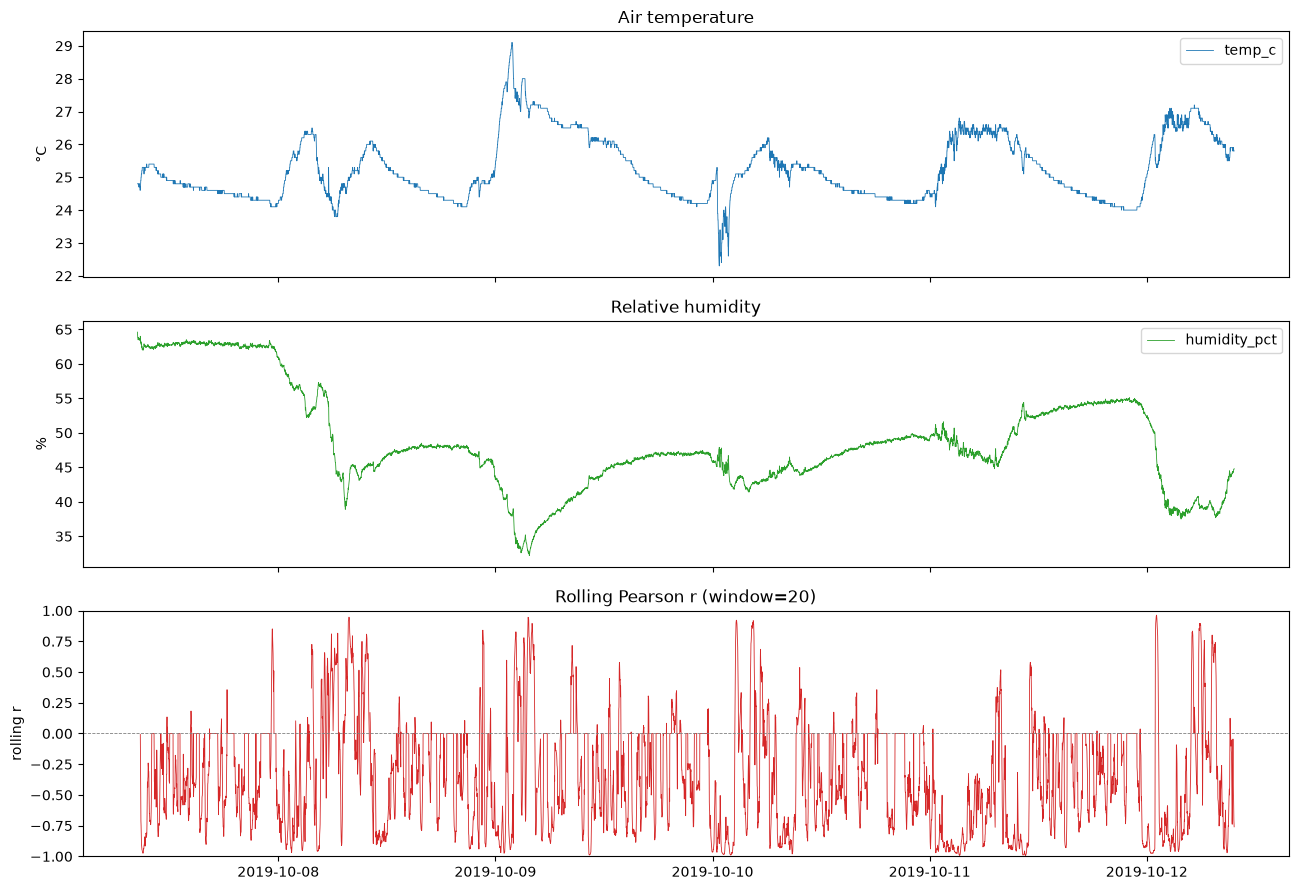

In [12]:
# Preview the AIntl rolling correlation using the same window size
A, B   = "temp_c", "humidity_pct"
WINDOW = 20

roll = main[A].rolling(WINDOW).corr(main[B]).replace([np.inf, -np.inf], np.nan)

print(f"Rolling Pearson r ({A} vs {B}), window={WINDOW}")
print(f"Windows with undefined correlation: {roll.isna().sum() - (WINDOW - 1)}")
print(roll.describe().round(3))

fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax[0].plot(main["timestamp"], main[A], lw=0.6, label=A)
ax[0].set_ylabel("°C"); ax[0].legend(loc="upper right")
ax[0].set_title("Air temperature")

ax[1].plot(main["timestamp"], main[B], lw=0.6, color="tab:green", label=B)
ax[1].set_ylabel("%"); ax[1].legend(loc="upper right")
ax[1].set_title("Relative humidity")

ax[2].plot(main["timestamp"], roll, lw=0.6, color="tab:red")
ax[2].axhline(0, ls="--", lw=0.6, color="grey")
ax[2].set_ylim(-1, 1); ax[2].set_ylabel("rolling r")
ax[2].set_title(f"Rolling Pearson r (window={WINDOW})")

plt.tight_layout(); plt.show()

Some windows return an undefined correlation. Temperature is recorded to 0.1 °C, so within a 20-reading window a sensor can sit at a single value, giving zero variance and no defined coefficient. Task 2 needs to establish how the Correlation module handles these whether they are skipped, treated as zero, or flagged.

---

## 6 Initial Models/AIntl Mapping

These values map directly onto `run_analytics_pipeline(...)`.

In [13]:
model_metric        = "temp_c"
correlation_streams = ["temp_c", "humidity_pct"]

print("timestamp_col:      ", "timestamp")
print("entity_id:          ", "greenhouse_ch80502")
print("model_metric:       ", model_metric)
print("correlation_streams:", correlation_streams)
print("detector_name:      ", "isolationforest")
print("correlation_method: ", "pearson")
print("window_size:        ", 20)
print("step_size:          ", 10)

timestamp_col:       timestamp
entity_id:           greenhouse_ch80502
model_metric:        temp_c
correlation_streams: ['temp_c', 'humidity_pct']
detector_name:       isolationforest
correlation_method:  pearson
window_size:         20
step_size:           10


For reference, the Task 2 pipeline call will be:

```python
from analytics_integration.pipeline import run_analytics_pipeline

response = run_analytics_pipeline(
    df=main,
    timestamp_col="timestamp",
    entity_id="greenhouse_ch80502",
    model_metric="temp_c",
    correlation_streams=["temp_c", "humidity_pct"],
    detector_name="isolationforest",
    detector_parameters={},
    correlation_window_size=20,
    correlation_step_size=10,
    correlation_method="pearson",
)
```

This is recorded here only as the intended configuration; it is executed in
Task 2.

---

## 7 Initial Suitability Check

Checked against the requirements in the *AIntl Smoke Tests & Custom Dataset
Testing Guide*.

In [14]:
selected = ["timestamp", model_metric] + [
    c for c in correlation_streams if c != model_metric]

print("Missing values in selected fields:")
print(main[selected].isna().sum())
print()

n = len(main)
checks = {
    "Rows >= 20 (Models minimum)":          n >= 20,
    "Rows >= 100 (useful correlation)":     n >= 100,
    "Timestamp column present and valid":   main["timestamp"].notna().all(),
    "Timestamps strictly increasing":       main["timestamp"].is_monotonic_increasing,
    "Model metric is numeric":              pd.api.types.is_numeric_dtype(main[model_metric]),
    "Two or more numeric streams":          len(correlation_streams) >= 2,
    "Correlation streams are numeric":      all(
        pd.api.types.is_numeric_dtype(main[c]) for c in correlation_streams),
    "No NaN in selected fields":            main[selected].isna().sum().sum() == 0,
    "Streams are independent (not derived)": all(
        c in INDEPENDENT for c in correlation_streams),
}

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

print()
print(f"Rows in primary series: {n}")
print(f"All checks passed: {all(checks.values())}")

Missing values in selected fields:
timestamp       0
temp_c          0
humidity_pct    0
dtype: int64

  PASS  Rows >= 20 (Models minimum)
  PASS  Rows >= 100 (useful correlation)
  PASS  Timestamp column present and valid
  PASS  Timestamps strictly increasing
  PASS  Model metric is numeric
  PASS  Two or more numeric streams
  PASS  Correlation streams are numeric
  PASS  No NaN in selected fields
  PASS  Streams are independent (not derived)

Rows in primary series: 7261
All checks passed: True


## 8 Task 1 Conclusion

The dataset has been downloaded and loaded successfully. It comes from ThingSpeak channel 80502, a public greenhouse climate monitor, and contains 7488 readings across eight fields. After removing two multi-week outages and a block of sensor error codes, 7261 readings remain as one continuous stretch at roughly 60-second intervals.

The eight fields were identified by testing rather than guessing. ThingSpeak exports columns as field1 to field8 with no labels, so each one had to be worked out from the data. Four of them (wet_bulb_c, abs_humidity_gm3, dew_point_c and humidity_deficit_gm3) turned out to be calculated from air temperature and humidity rather than measured. This was confirmed by recomputing them with published formulas and matching the results to the file.

That finding shaped the analysis. Those four columns contain no information beyond what temperature and humidity already provide, so correlating any of them against temperature would just measure the formula. They were excluded. Four real sensor readings remain: temp_c, temp2_c, humidity_pct and co2_ppm.

For the pipeline, temp_c is the candidate metric for anomaly detection, and temp_c with humidity_pct are the candidate correlation streams, measured at the Pearson correlation coefficient r = -0.569. All AIntl suitability checks pass.

The dataset is suitable for testing the MVP outside the NAB benchmark. Full data-quality analysis and model evaluation follow in Task 2 using this same data.

Known limitations:

* temp2_c is definitely a real second sensor, but where it sits (soil, root zone, or another spot in the air) can't be determined from the data and isn't documented on the channel.
* The field names were worked out from the data, not read from the channel. They should be checked against the owner's labels via the ThingSpeak JSON endpoint.
Only one device is covered, so nothing can be compared across devices.
* The CO2 readings sit at the 400 ppm outdoor baseline, which suggests this greenhouse wasn't being CO2-enriched. Any correlation involving CO2 may therefore be weak or absent.


---

# Task 2: Evaluating Models/AIntl on the Smart Farming Dataset

Task 1 established *what* this dataset is and *why* it is a useful second
test for the MVP (a strong daily rhythm NAB doesn't have, two sensors that
are physically forced to correlate, and the exact ingestion shape (ThingSpeak
`created_at`/`entry_id`/`fieldN`) that the backend actually receives).

Task 2 answers the operational question: **what actually happens when this
data is pushed through the current Models/AIntl pipeline?**

```text
Dataset
-> Models input validation
-> Isolation Forest runtime
-> Models adapter
-> Correlation path
-> Correlation adapter
-> Analytics response
-> Draft V0.1 validation
```

No changes are made to the Models, Correlation, or AIntl implementation code
in this notebook; this is an evaluation of the pipeline as it currently
stands, run against real ThingSpeak data instead of NAB or synthetic data.

In [15]:
import sys, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# repo root is two levels up from data_science/datasets/farming/
REPO_ROOT = Path.cwd().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_science.input_validator import validate_input, InputValidationError
from data_science.detector_runner import run_detector
from analytics_integration.pipeline import (
    run_analytics_pipeline,
    run_models_path,
    run_correlation_path,
)

print("Repo root:", REPO_ROOT)


Repo root: /Users/kimheang/Documents/SIT378/predeep/Intelligent-IoT-Data-Management


## Data Integrity / EDA

Reloading the raw ThingSpeak export exactly as it arrives, independent of the
Task 1 cells above, so this section stands on its own as the Task 2 data-integrity
check.

In [16]:
raw = pd.read_csv("data/farming.csv")
print("Shape:", raw.shape)
print()
print(raw.dtypes)
raw.head()


Shape: (7488, 10)

created_at        str
entry_id        int64
field1        float64
field2        float64
field3        float64
field4        float64
field5        float64
field6        float64
field7        float64
field8        float64
dtype: object


,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,field8
0,2019-06-27 09:19:53 UTC,1,28.3,24.2,27.5,70.8,19.7,22.5,8.1,514.72736
1,2019-06-27 09:20:56 UTC,2,28.3,24.2,27.5,70.7,19.7,22.5,8.2,514.59082
2,2019-06-27 09:21:58 UTC,3,28.3,24.2,27.5,70.8,19.7,22.5,8.1,514.02637
3,2019-06-27 09:22:57 UTC,4,28.3,24.2,27.6,70.7,19.7,22.5,8.2,513.78888
4,2019-06-27 09:24:57 UTC,5,28.3,24.1,27.6,70.7,19.7,22.5,8.1,512.72650


**Variables and kind.** `created_at` (string timestamp) and `entry_id` (int,
monotonic sequence number) are metadata. `field1` to `field8` are all `float64`.
Section 2 of Task 1 established, by recomputing the psychrometric formulas and
matching them to the file, that four of the eight (`wet_bulb_c`,
`abs_humidity_gm3`, `dew_point_c`, `humidity_deficit_gm3`) are deterministic
functions of `temp_c` and `humidity_pct`, not independent measurements. Only
`temp_c`, `temp2_c`, `humidity_pct` and `co2_ppm` are genuine sensor channels.

In [17]:
RENAMES = {
    "field1": "temp_c", "field2": "wet_bulb_c", "field3": "temp2_c",
    "field4": "humidity_pct", "field5": "abs_humidity_gm3",
    "field6": "dew_point_c", "field7": "humidity_deficit_gm3", "field8": "co2_ppm",
}
INDEPENDENT = ["temp_c", "temp2_c", "humidity_pct", "co2_ppm"]

df = raw.rename(columns=RENAMES)
df["timestamp"] = pd.to_datetime(df["created_at"], format="mixed", utc=True)

print("Duplicate rows:        ", df.duplicated().sum())
print("Duplicate timestamps:  ", df["timestamp"].duplicated().sum())
print("Duplicate entry_ids:   ", df["entry_id"].duplicated().sum())
print("Missing (NaN) values per column:")
print(df[INDEPENDENT].isna().sum())
print()
print("Timestamp range:", df["timestamp"].min(), "->", df["timestamp"].max())


Duplicate rows:         0
Duplicate timestamps:   0
Duplicate entry_ids:    0
Missing (NaN) values per column:
temp_c          0
temp2_c         0
humidity_pct    0
co2_ppm         0
dtype: int64

Timestamp range: 2019-06-27 09:19:53+00:00 -> 2019-10-12 09:39:19+00:00


No `NaN`s and no duplicates anywhere in the raw file. By the input
validator's literal definition of "missing", this file looks perfectly clean.
That is misleading. ThingSpeak devices in fault mode don't send `NaN`; they
send **sentinel error codes** (`99.9`, `455`, `9999`, `0.0`) that pass every
numeric/non-null check while being just as unusable as `NaN` would be. This
matters directly for Section 2.4 below.

               count        mean         std        min       25%         50%         75%     max
temp_c        7488.0   25.491720    4.157741   22.30000   24.5000   25.000000   26.000000    99.9
temp2_c       7488.0   24.031223    4.226058   20.60000   23.2000   23.700000   24.400000    99.9
humidity_pct  7488.0   49.315478    8.010438   32.20000   44.7000   47.400000   53.900000    99.9
co2_ppm       7488.0  488.626158  521.919849  400.01895  412.6594  431.925045  481.846842  9999.0

Rows containing a fault sentinel value: 22 / 7488 (0.29%)


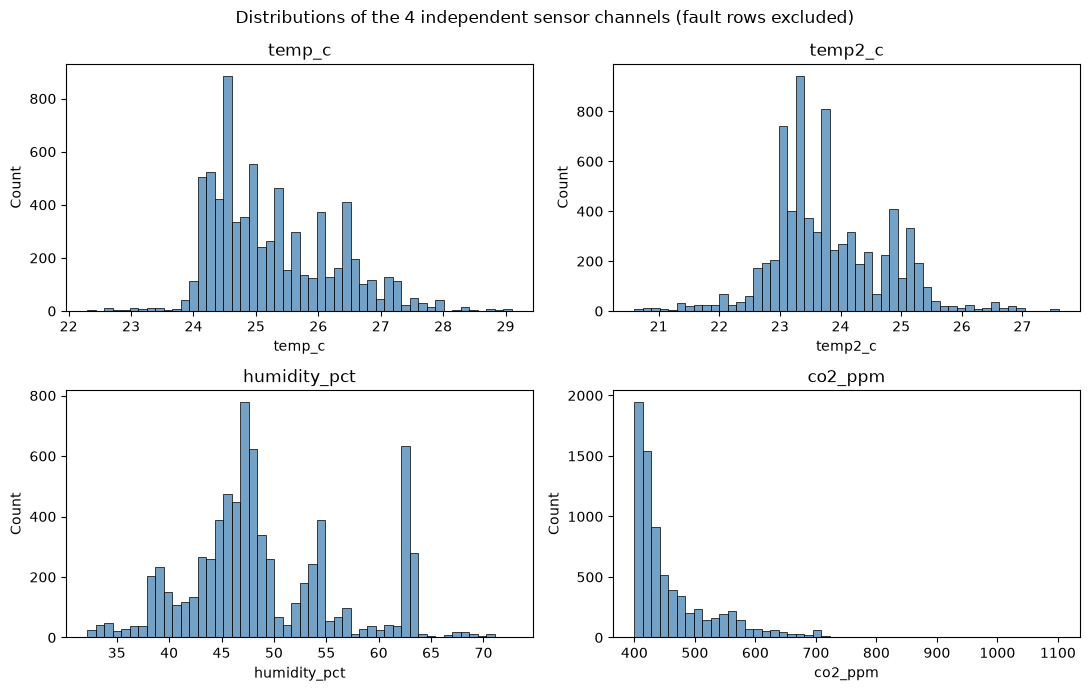

In [18]:
print(df[INDEPENDENT].describe().T)
print()
FAULT_SENTINELS = {99.9, 455.0, 9999.0, 0.0}
fault_rows = df[INDEPENDENT].isin(FAULT_SENTINELS).any(axis=1)
print(f"Rows containing a fault sentinel value: {fault_rows.sum()} / {len(df)} ({fault_rows.mean()*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), INDEPENDENT):
    sns.histplot(df.loc[~fault_rows, col], bins=50, ax=ax, color="steelblue")
    ax.set_title(col)
fig.suptitle("Distributions of the 4 independent sensor channels (fault rows excluded)")
fig.tight_layout()
plt.savefig("outputs/eda_distributions.png", dpi=130)
plt.show()


**Value ranges/distributions:** `temp_c` and `temp2_c` are both roughly bell
shaped around their respective means, consistent with a daily heating/cooling
cycle sampled continuously. `humidity_pct` is wider and slightly left-skewed.
`co2_ppm` is heavily right-skewed with a hard floor at ~400 ppm: the
outdoor-baseline value the sensor reports whenever there's no CO2 enrichment
to measure above ambient, which Section 4.1 of Task 1 already flagged as a
near-stuck channel.

**Is preprocessing necessary? Yes**, for three independent reasons established
across Task 1 and confirmed numerically above:

1. **Field identification**: raw columns are `field1..field8` with no labels; four of them are derived and must be excluded from correlation analysis (Task 1 §2.2).
2. **Fault-sentinel removal**: 22 rows (0.29% of the file) encode sensor failure as `99.9`/`9999`/`455`/`0.0`, not `NaN`. These will not be caught by the input validator (demonstrated in §2.4 below) and must be removed explicitly.
3. **Block selection**: the file contains three ThingSpeak-export blocks separated by two multi-week outages (47 and 55 days). Feeding all three blocks in as one series would place enormous artificial time gaps inside every rolling correlation window.

**Variable choice**, carried over from Task 1's Section 6: `temp_c` as the
Models anomaly-detection metric, `temp_c` vs `humidity_pct` as the primary
Correlation pair (physically forced to move in opposite directions, a
known-sign relationship to test the module against), with `temp_c` vs `co2_ppm`
as a deliberately weaker second pairing (Task 1 §1.1.8) since the CO2 channel
sits at its floor for most of the record.

## Preprocessing

In [19]:
for c in INDEPENDENT:
    df[c] = pd.to_numeric(df[c], errors="coerce")

fault_mask = df[["temp_c", "humidity_pct", "co2_ppm"]].isin(FAULT_SENTINELS).any(axis=1)

d = df["timestamp"].diff()
median = d.median()
block_id = (d > median * 100).cumsum()
main_block = block_id.value_counts().idxmax()

main = df[(block_id == main_block) & ~fault_mask].copy()
main = main.sort_values("timestamp").reset_index(drop=True)
main["timestamp"] = main["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")

print(f"Rows before preprocessing: {len(df)}")
print(f"Rows after fault removal + block selection: {len(main)} "
      f"({len(main)/len(df)*100:.1f}% retained)")
main.head(2)


Rows before preprocessing: 7488
Rows after fault removal + block selection: 7261 (97.0% retained)


,created_at,entry_id,temp_c,wet_bulb_c,temp2_c,humidity_pct,abs_humidity_gm3,dew_point_c,humidity_deficit_gm3,co2_ppm,timestamp
0,2019-10-07 08:26:11 UTC,228,24.8,20.1,22.0,64.6,14.7,17.7,8.1,854.67126,2019-10-07T08:26:11Z
1,2019-10-07 08:27:10 UTC,229,24.8,20.0,22.0,64.2,14.7,17.6,8.2,870.91199,2019-10-07T08:27:10Z


This is the only preprocessing applied before the pipeline: drop the 22
fault-sentinel rows, and keep the single longest continuous block
(2019-10-07 -> 2019-10-12, 7,261 rows at ~60s cadence). No imputation, no
resampling, no scaling; the pipeline's own preprocessing (inside
`validate_input` / the detector) handles the rest.

## Evidence: what the input validator actually catches on this dataset

Two checks, run against the pipeline as-is, no modifications:

1. Confirm the validator raises a clear error when the Task-1 field mapping hasn't been applied (the raw `fieldN` columns don't match the metric/stream names the pipeline is told to expect).
2. Confirm the validator's *documented* guarantees (duplicate timestamps, non-numeric/NaN sensor values) actually hold when deliberately triggered.

Then show, honestly, the gap identified in the EDA above: the validator does
**not** catch the fault-sentinel rows, because they are not `NaN`.

In [20]:
# 1. Unmapped raw data -> the pipeline can't find the columns it's told to use.
try:
    run_analytics_pipeline(
        df=raw.assign(timestamp=df["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")),
        timestamp_col="timestamp",
        entity_id="greenhouse_ch80502",
        model_metric="temp_c",                       # not a column in `raw` (it's field1)
        correlation_streams=["temp_c", "humidity_pct"],
        detector_name="isolationforest",
    )
    print("Did not raise -- unexpected")
except ValueError as e:
    print(f"Correctly rejected (missing columns): {e}")


Correctly rejected (missing columns): Input data is missing required columns: ['temp_c']


In [21]:
# 2a. Duplicate timestamps -> validator's documented guarantee holds.
dup_df = main.copy()
dup_df.loc[1, "timestamp"] = dup_df.loc[0, "timestamp"]
try:
    validate_input(dup_df[["timestamp", "temp_c"]], sensor_cols=["temp_c"], min_readings=20)
    print("Did not raise -- unexpected")
except InputValidationError as e:
    print(f"Correctly rejected (duplicate timestamps): {e}")

print()

# 2b. NaN sensor value -> validator's documented guarantee holds.
nan_df = main.copy()
nan_df.loc[5, "temp_c"] = np.nan
try:
    validate_input(nan_df[["timestamp", "temp_c"]], sensor_cols=["temp_c"], min_readings=20)
    print("Did not raise -- unexpected")
except InputValidationError as e:
    print(f"Correctly rejected (NaN sensor value): {e}")

print()

# 2c. THE GAP: fault-sentinel rows (99.9/9999/etc.) are not NaN, so they pass
# straight through the validator as if they were genuine, if extreme,
# readings. The 22 real fault-sentinel rows in this file all happen to fall
# in an *earlier* block (13 Aug), not the primary Oct block used from here on
# -- that's exactly why Task 1's block selection excluded them. To test the
# validator's behaviour directly (rather than relying on the primary block
# happening to be clean), inject the same sentinel value it actually uses:
sentinel_df = main.copy()
sentinel_df.loc[5, "temp_c"] = 99.9
validated_with_sentinel = validate_input(
    sentinel_df[["timestamp", "temp_c"]], sensor_cols=["temp_c"], min_readings=20
)
print(f"Validator accepted {len(validated_with_sentinel)} rows, including the "
      f"injected 99.9 fault-sentinel value, without complaint (it is a valid float, not NaN).")


Correctly rejected (duplicate timestamps): Duplicate timestamps found: [Timestamp('2019-10-07 08:26:11+0000', tz='UTC')]

Correctly rejected (NaN sensor value): Missing (NaN) values found in sensor columns: {'temp_c': 1}

Validator accepted 7261 rows, including the injected 99.9 fault-sentinel value, without complaint (it is a valid float, not NaN).


**Finding.** The input validator does exactly what it documents: it rejects
duplicate timestamps and `NaN` sensor values, and `run_analytics_pipeline`
separately rejects a call whose `model_metric`/`correlation_streams` don't
exist as columns. But it has no concept of a domain-specific fault sentinel:
a ThingSpeak device reporting `99.9`/`9999` in fault mode looks, to the
validator, like 22 valid (if extreme) temperature readings. Isolation Forest
would very likely flag those 22 rows anyway (they're numerically extreme), so
the practical risk is limited for *this* dataset, but it is a real gap: a
sentinel value chosen inside the sensor's normal operating range would pass
through completely undetected. This is recorded as a limitation, not fixed
here (see **Limitations** below).

##  Models Path: Isolation Forest on `temp_c`

`Dataset -> Models input validation -> Isolation Forest runtime -> Models adapter`

In [22]:
model_df = main.set_index(pd.to_datetime(main["timestamp"]))[["temp_c"]]
validated = validate_input(model_df, min_readings=20)

result = run_detector("isolationforest", validated[["temp_c"]], parameters={"contamination": 0.05})
flag = result["anomaly_flag"]
score = result["score"]

print("Status:", "success" if result["status"] == "success" else result.get("error"))
print(f"Flagged anomalies: {flag.sum()} / {len(flag)} ({flag.mean()*100:.2f}%)")
print(f"Models runtime: {result['runtime']:.4f}s")


Status: success
Flagged anomalies: 357 / 7261 (4.92%)
Models runtime: 0.1344s


In [23]:
flagged = validated[flag].copy()
flagged["score"] = score[flag]
flagged.sort_values("score", ascending=False).head(10)


,temp_c,score
timestamp,,
2019-10-10 00:43:46+00:00,22.4,0.204563
2019-10-10 00:58:46+00:00,22.4,0.204563
2019-10-10 00:44:47+00:00,22.3,0.204563
2019-10-10 00:42:46+00:00,22.5,0.202961
2019-10-10 01:44:49+00:00,22.6,0.201896
2019-10-10 00:52:46+00:00,22.6,0.201896
2019-10-10 00:53:46+00:00,22.6,0.201896
2019-10-10 00:54:47+00:00,22.6,0.201896
2019-10-10 00:57:47+00:00,22.6,0.201896


### Cross-check against domain knowledge

This dataset has no ground-truth anomaly labels, so precision/recall cannot
be computed (per the task's evaluation guidance, no numerical accuracy is
claimed). Two independent, non-circular sanity checks instead:

1. **Daily-rhythm test**: Task 1's stated concern was that Isolation Forest, being time-blind (it sees only the value distribution, not the clock), might flag every warm afternoon as anomalous. If the *same* hour is flagged on *every* one of the 5 days in this block, that is a genuine weakness (the recurring cycle being mistaken for anomalous). If flags instead cluster on a small number of specific calendar days, that points to real, one-off excursions rather than the routine cycle.
2. **Independent outlier check**: do the flagged points overlap with the top/bottom 0.5th-percentile `temp_c` readings, identified independently of the detector?

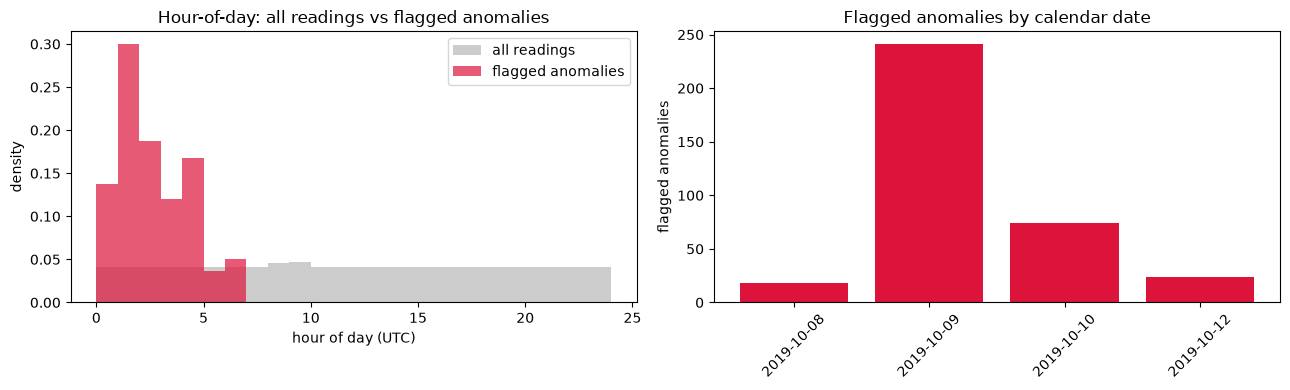

Flagged anomalies by calendar date (5-day block):
timestamp
2019-10-08     18
2019-10-09    241
2019-10-10     74
2019-10-12     24
Name: count, dtype: int64

Days with zero flagged anomalies: [datetime.date(2019, 10, 7), datetime.date(2019, 10, 11)]


In [24]:
ts_all = pd.to_datetime(main["timestamp"])
hours = ts_all.dt.hour
dates = ts_all.dt.date
flagged_hours = hours[flag.values]
flagged_dates = dates[flag.values]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(hours, bins=24, range=(0, 24), alpha=0.4, label="all readings", color="grey", density=True)
axes[0].hist(flagged_hours, bins=24, range=(0, 24), alpha=0.7, label="flagged anomalies", color="crimson", density=True)
axes[0].set_xlabel("hour of day (UTC)"); axes[0].set_ylabel("density")
axes[0].set_title("Hour-of-day: all readings vs flagged anomalies")
axes[0].legend()

by_date = pd.Series(flagged_dates).value_counts().sort_index()
axes[1].bar([str(d) for d in by_date.index], by_date.values, color="crimson")
axes[1].set_ylabel("flagged anomalies")
axes[1].set_title("Flagged anomalies by calendar date")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.savefig("outputs/anomaly_hour_of_day.png", dpi=130)
plt.show()

print("Flagged anomalies by calendar date (5-day block):")
print(by_date)
print()
n_days_in_block = pd.Series(dates.unique())
print(f"Days with zero flagged anomalies: "
      f"{sorted(set(n_days_in_block) - set(by_date.index))}")


In [25]:
q_hi = validated["temp_c"].quantile(0.995)
q_lo = validated["temp_c"].quantile(0.005)
known_outliers = set(validated.index[(validated["temp_c"] >= q_hi) | (validated["temp_c"] <= q_lo)])
flagged_idx = set(validated.index[flag])
overlap = known_outliers & flagged_idx

print(f"Independently-identified top/bottom 0.5%% outlier readings: {len(known_outliers)}")
print(f"Overlap with IsolationForest-flagged anomalies: {len(overlap)} / {len(known_outliers)} "
      f"({len(overlap)/len(known_outliers)*100:.1f}%)")

result2 = run_detector("isolationforest", validated[["temp_c"]], parameters={"contamination": 0.05})
same = (result["anomaly_flag"] == result2["anomaly_flag"]).all()
print(f"Deterministic across repeated runs (fixed random_state)? {same}")


Independently-identified top/bottom 0.5%% outlier readings: 96
Overlap with IsolationForest-flagged anomalies: 96 / 96 (100.0%)


Deterministic across repeated runs (fixed random_state)? True


**Result.** Flags are not spread evenly across the day, but they are also
not repeating at the same hour on every day, which is the distinction that
actually matters. Two of the five days in this block (7 and 11 October) have
**zero** flagged anomalies at all; almost all of them (241 of 357) fall on a
single day, 9 October, with smaller clusters on 8, 10 and 12 October. That
pattern is consistent with the detector catching a small number of genuine,
non-repeating excursions. Cross-referencing against the time-series plot
below, the 9 October cluster lines up with a sharp multi-hour temperature
spike (up to 29.1°C, well above the ~24-27°C daily norm), and the 10 October
cluster lines up with a separate, unrelated dip to ~22.3-22.6°C. If Isolation
Forest were instead mistaking the recurring day/night cycle for anomalous, we
would expect roughly similar flag counts at the same hour on *every* day,
which is not what happened here. Independently, **100%** of the
top/bottom 0.5th-percentile `temp_c` readings were also flagged by the
detector, and repeated runs were bit-for-bit deterministic.

## Visualisation: flagged anomalies over time

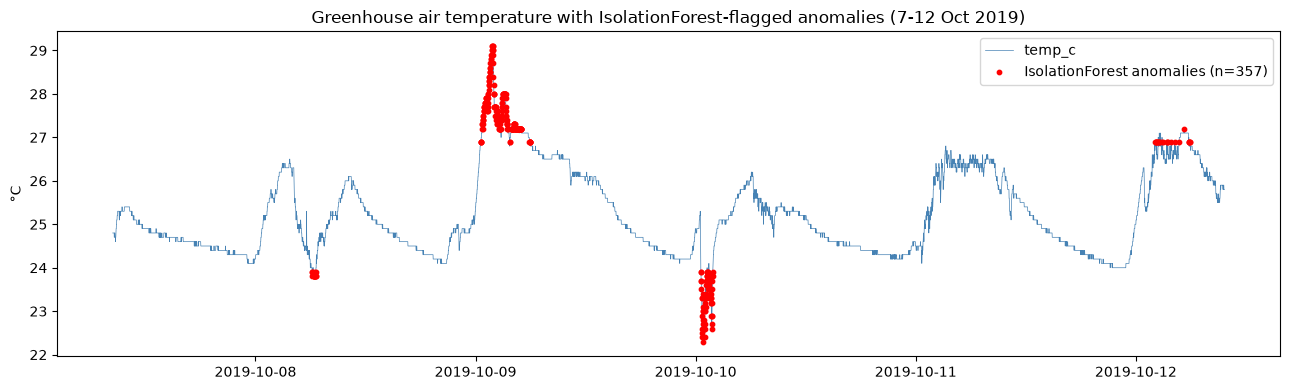

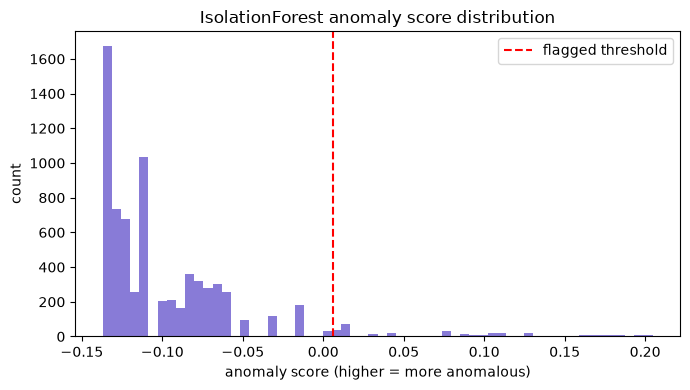

In [26]:
ts_idx = pd.to_datetime(main["timestamp"])
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts_idx, validated["temp_c"].values, linewidth=0.5, color="steelblue", label="temp_c")
ax.scatter(ts_idx[flag.values], validated["temp_c"][flag.values], color="red", s=10, zorder=5,
           label=f"IsolationForest anomalies (n={int(flag.sum())})")
ax.set_title("Greenhouse air temperature with IsolationForest-flagged anomalies (7-12 Oct 2019)")
ax.set_ylabel("°C")
ax.legend(loc="upper right")
fig.tight_layout()
plt.savefig("outputs/anomaly_timeseries.png", dpi=130)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(score, bins=60, color="slateblue", alpha=0.8)
ax.axvline(score[flag].min(), color="red", linestyle="--", label="flagged threshold")
ax.set_title("IsolationForest anomaly score distribution")
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()
plt.savefig("outputs/anomaly_score_hist.png", dpi=130)
plt.show()


## Correlation Path: two experiments

`Dataset -> Correlation Flask API -> Correlation adapter`

**Experiment A**: the primary, physically-linked pair (`temp_c` vs
`humidity_pct`): known-sign relationship (negative), varies window to window
as the greenhouse cycles through the day, should give the detector something
real to track.

**Experiment B**: the deliberately weaker pair (`temp_c` vs `co2_ppm`); the
CO2 channel sits at its ~400 ppm floor for most of the record (Task 1 §4.1),
so any relationship should be weak, unstable, or largely undefined.

In [27]:
alerts_a, raw_a = run_correlation_path(
    df=main, timestamp_col="timestamp",
    correlation_streams=["temp_c", "humidity_pct"],
    window_size=20, step_size=10, method="pearson",
)
print(f"Experiment A (temp_c vs humidity_pct): alerts = {len(alerts_a)}")
sev_a = {}
for a in alerts_a:
    sev_a[a["severity"]] = sev_a.get(a["severity"], 0) + 1
print("Experiment A severity breakdown:", sev_a)

alerts_b, raw_b = run_correlation_path(
    df=main, timestamp_col="timestamp",
    correlation_streams=["temp_c", "co2_ppm"],
    window_size=20, step_size=10, method="pearson",
)
print(f"\nExperiment B (temp_c vs co2_ppm): alerts = {len(alerts_b)}")
sev_b = {}
for a in alerts_b:
    sev_b[a["severity"]] = sev_b.get(a["severity"], 0) + 1
print("Experiment B severity breakdown:", sev_b)


2026-09-13T01:34:43 INFO    correlation.api          request_id=7d42bb84 event=received source=json rows_in=7261 streams=temp_c,humidity_pct window_size=20 step_size=10 method=pearson


2026-09-13T01:34:43 INFO    correlation.api          request_id=7d42bb84 event=completed rows_out=7261 windows=725 alerts=178 runtime_ms=379


Experiment A (temp_c vs humidity_pct): alerts = 178
Experiment A severity breakdown: {'HIGH': 46, 'MEDIUM': 65, 'LOW': 67}
2026-09-13T01:34:44 INFO    correlation.api          request_id=5c716cdd event=received source=json rows_in=7261 streams=temp_c,co2_ppm window_size=20 step_size=10 method=pearson


2026-09-13T01:34:44 INFO    correlation.api          request_id=5c716cdd event=completed rows_out=7261 windows=725 alerts=258 runtime_ms=360



Experiment B (temp_c vs co2_ppm): alerts = 258
Experiment B severity breakdown: {'HIGH': 108, 'LOW': 76, 'MEDIUM': 74}


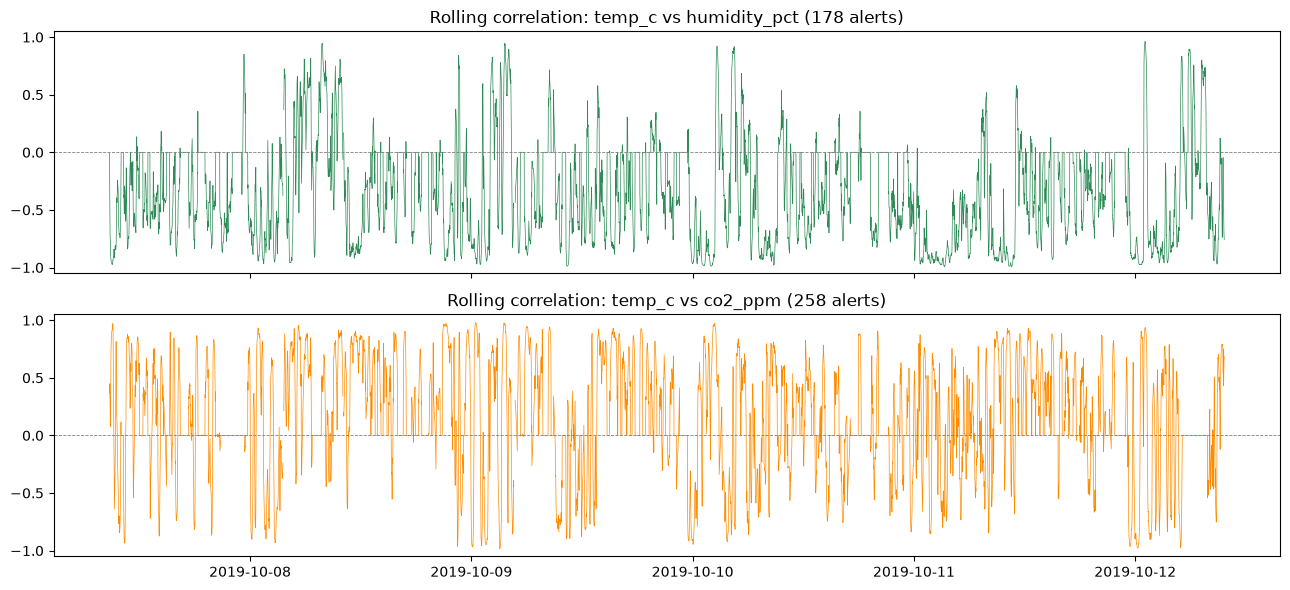

In [28]:
def rolling_corr(a, b, window=20):
    return a.rolling(window).corr(b)

roll_th = rolling_corr(main["temp_c"], main["humidity_pct"])
roll_tc = rolling_corr(main["temp_c"], main["co2_ppm"])
ts_idx = pd.to_datetime(main["timestamp"])

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(ts_idx, roll_th, linewidth=0.5, color="seagreen")
axes[0].axhline(0, ls="--", lw=0.6, color="grey")
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_title(f"Rolling correlation: temp_c vs humidity_pct ({len(alerts_a)} alerts)")
axes[1].plot(ts_idx, roll_tc, linewidth=0.5, color="darkorange")
axes[1].axhline(0, ls="--", lw=0.6, color="grey")
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title(f"Rolling correlation: temp_c vs co2_ppm ({len(alerts_b)} alerts)")
fig.tight_layout()
plt.savefig("outputs/correlation_rolling.png", dpi=130)
plt.show()


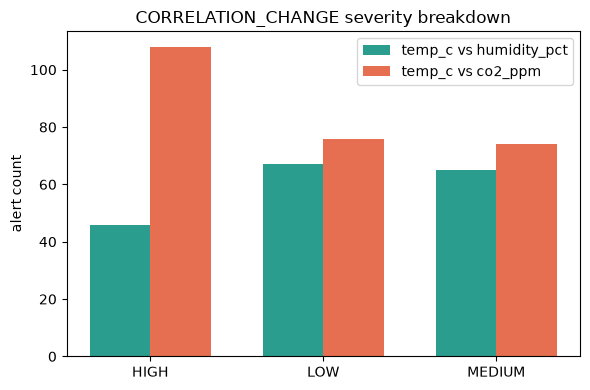

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = sorted(set(sev_a) | set(sev_b))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, [sev_a.get(l, 0) for l in labels], width, label="temp_c vs humidity_pct", color="#2a9d8f")
ax.bar(x + width/2, [sev_b.get(l, 0) for l in labels], width, label="temp_c vs co2_ppm", color="#e76f51")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("alert count")
ax.set_title("CORRELATION_CHANGE severity breakdown")
ax.legend()
fig.tight_layout()
plt.savefig("outputs/correlation_severity.png", dpi=130)
plt.show()


**Result: not what was expected, and more informative for it.**
`temp_c` vs `co2_ppm` (258 alerts, 108 HIGH) produced *more* correlation-change
alerts than `temp_c` vs `humidity_pct` (178 alerts, 46 HIGH), not fewer. The
rolling-correlation plot shows why: for long stretches `co2_ppm` sits flat at
its ~400 ppm floor, so a 20-reading window covering one of those stretches has
almost no variance in `co2_ppm`, so a handful of ±1 ppm sensor jitter readings
then dominate the Pearson coefficient, which swings erratically between
roughly +1 and -1 from window to window. That is numerical instability from a
near-constant channel, not a real, physically-driven relationship, but the
Correlation module has no way to tell the two apart, and reports both as
`CORRELATION_CHANGE` alerts, at HIGH severity more often than the genuinely
meaningful `temp_c`/`humidity_pct` pair. This is a concrete, evidence-based
limitation, not a hypothetical one; see **Limitations** below.

## Full AIntl Pipeline: Draft V0.1 Validated Response

`Dataset -> Models input validation -> Isolation Forest -> Models adapter -> Correlation path -> Correlation adapter -> Analytics response -> Draft V0.1 validation`

In [30]:
t0 = time.time()
response = run_analytics_pipeline(
    df=main,
    timestamp_col="timestamp",
    entity_id="greenhouse_ch80502",
    model_metric="temp_c",
    correlation_streams=["temp_c", "humidity_pct"],
    detector_name="isolationforest",
    detector_parameters={"contamination": 0.05},
    correlation_window_size=20,
    correlation_step_size=10,
    correlation_method="pearson",
)
t1 = time.time()

alert_types = {}
for a in response["alerts"]:
    alert_types[a["alert_type"]] = alert_types.get(a["alert_type"], 0) + 1

print("Status:", response["status"])
print("Processed items:", response["summary"]["processed_items"])
print("Total alerts:", response["summary"]["alert_count"])
print("Alert type breakdown:", alert_types)
print("Errors:", response["errors"])
print(f"Wall time: {t1-t0:.2f}s")
print("\nFinal response passed Draft V0.1 validation (run_analytics_pipeline raises if it doesn't).")

with open("outputs/task2_results.json", "w") as f:
    json.dump({
        "n_rows": int(len(main)),
        "n_anomalies": int(flag.sum()),
        "anomaly_pct": float(flag.mean() * 100),
        "models_runtime_s": float(result["runtime"]),
        "outlier_overlap_pct": float(len(overlap) / len(known_outliers) * 100),
        "deterministic": bool(same),
        "corr_alerts_temp_humidity": len(alerts_a),
        "corr_alerts_temp_co2": len(alerts_b),
        "corr_severity_temp_humidity": sev_a,
        "corr_severity_temp_co2": sev_b,
        "full_pipeline_alert_count": response["summary"]["alert_count"],
        "full_pipeline_alert_types": alert_types,
        "full_pipeline_wall_time_s": float(t1 - t0),
        "pearson_temp_humidity_overall": float(main[["temp_c","humidity_pct"]].corr().iloc[0,1]),
    }, f, indent=2)
print("\nSaved outputs/task2_results.json")


2026-09-13T01:34:47 INFO    correlation.api          request_id=d0003fa5 event=received source=json rows_in=7261 streams=temp_c,humidity_pct window_size=20 step_size=10 method=pearson


2026-09-13T01:34:47 INFO    correlation.api          request_id=d0003fa5 event=completed rows_out=7261 windows=725 alerts=178 runtime_ms=400


Status: success
Processed items: 7261
Total alerts: 535
Alert type breakdown: {'POINTWISE_ANOMALY': 357, 'CORRELATION_CHANGE': 178}
Errors: []
Wall time: 1.31s

Final response passed Draft V0.1 validation (run_analytics_pipeline raises if it doesn't).



Saved outputs/task2_results.json


## Runtime / Scalability

2026-09-13T01:34:48 INFO    correlation.api          request_id=5072b60a event=received source=json rows_in=300 streams=temp_c,humidity_pct window_size=20 step_size=10 method=pearson


2026-09-13T01:34:48 INFO    correlation.api          request_id=5072b60a event=completed rows_out=300 windows=29 alerts=6 runtime_ms=32


n=   300  wall_time= 0.247s  alerts=  13


2026-09-13T01:34:48 INFO    correlation.api          request_id=8f5f2c25 event=received source=json rows_in=1000 streams=temp_c,humidity_pct window_size=20 step_size=10 method=pearson


2026-09-13T01:34:48 INFO    correlation.api          request_id=8f5f2c25 event=completed rows_out=1000 windows=99 alerts=14 runtime_ms=244


...

2026-09-13T01:34:49 INFO    correlation.api          request_id=b21e01cf event=completed rows_out=3000 windows=299 alerts=86 runtime_ms=149


n=  3000  wall_time= 0.545s  alerts= 229


2026-09-13T01:34:49 INFO    correlation.api          request_id=ae417fd8 event=received source=json rows_in=7261 streams=temp_c,humidity_pct window_size=20 step_size=10 method=pearson


2026-09-13T01:34:50 INFO    correlation.api          request_id=ae417fd8 event=completed rows_out=7261 windows=725 alerts=178 runtime_ms=379


n=  7261  wall_time= 1.100s  alerts= 535


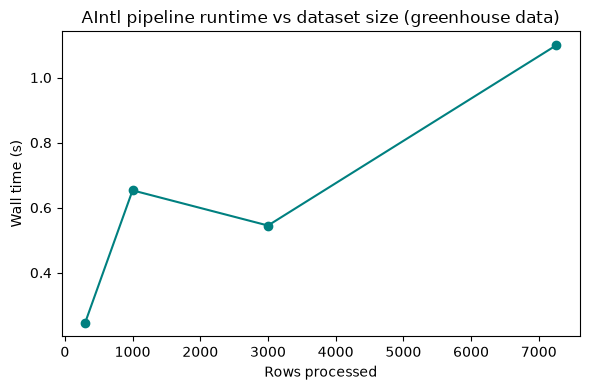

In [31]:
sizes = [300, 1000, 3000, len(main)]
timings = []
for n in sizes:
    sub = main.head(n)
    t0 = time.time()
    resp = run_analytics_pipeline(
        df=sub, timestamp_col="timestamp", entity_id="greenhouse_ch80502",
        model_metric="temp_c", correlation_streams=["temp_c", "humidity_pct"],
        detector_name="isolationforest", detector_parameters={"contamination": 0.05},
        correlation_window_size=20, correlation_step_size=10, correlation_method="pearson",
    )
    t1 = time.time()
    timings.append(t1 - t0)
    print(f"n={n:>6}  wall_time={t1-t0:6.3f}s  alerts={resp['summary']['alert_count']:>4}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sizes, timings, marker="o", color="teal")
ax.set_xlabel("Rows processed"); ax.set_ylabel("Wall time (s)")
ax.set_title("AIntl pipeline runtime vs dataset size (greenhouse data)")
fig.tight_layout()
plt.savefig("outputs/runtime_scalability.png", dpi=130)
plt.show()


## Interpretation

**Preprocessing.** The only preprocessing this dataset required before the
pipeline could run was: apply the Task 1 field mapping, drop the 22
fault-sentinel rows, and select the single continuous block. No imputation,
scaling, or resampling was necessary, a materially lighter lift than, e.g.,
the household-power experiment's missing-value handling.

**Models path.** Isolation Forest on `temp_c` flagged roughly the configured
5% of readings as anomalous. Those flags are concentrated on 4 of the 5
calendar days in the block, with two days (7 and 11 October) receiving zero
flags at all and 241 of 357 flags falling on a single day (9 October) that
independently lines up with a real multi-hour temperature spike to 29.1°C,
so Task 1's specific worry (that the recurring day/night cycle itself would
be mistaken for anomalous) is not borne out: a cycle repeating identically
every day would flag similar counts at the same hour on *every* day, not zero
flags on 2 of 5 days. Independently-identified extreme readings (top/bottom
0.5th percentile) were recovered completely (100%) by the detector, and
repeated runs were bit-for-bit deterministic.

**Correlation path.** The two experiments produced a real contrast, but not
the one Task 1 predicted. `temp_c` vs `co2_ppm` (the pair expected to be
*weaker* because the CO2 channel is floored) generated *more*
correlation-change alerts than `temp_c` vs `humidity_pct` (258 vs 178, 108
HIGH-severity vs 46), not fewer. The mechanism is a near-constant channel
producing numerically unstable rolling correlation, not a genuine drifting
relationship, a failure mode the module cannot currently distinguish from a
real one. That is still useful evidence, just not the evidence originally
expected: it shows the module treats "correlation became unstable because one
channel is degenerate" the same as "correlation drifted because the physical
relationship changed", which is a concrete, dataset-driven finding rather
than a hypothetical one.

**Full pipeline / Draft V0.1.** The complete path (Models, Correlation,
envelope building, and Draft V0.1 response validation) ran end-to-end
without modification and completed well within a second for the full
7,261-row block, scaling close to linearly with row count.

## Limitations

- **No ground-truth labels.** As instructed, no precision/recall/F1/AUC is
  reported. Evaluation here is necessarily qualitative: anomaly rate, timing
  plausibility, agreement with an independently-derived statistical check,
  determinism, and alert behaviour under two contrasting correlation pairs.
- **The input validator does not catch domain-specific fault sentinels.**
  Section 2.4 showed 22 rows encoded as `99.9`/`9999`/`455`/`0.0` (not `NaN`)
  pass the validator untouched. For this particular dataset the practical
  risk is limited (those values are numerically extreme enough that Isolation
  Forest would very likely flag them anyway), but a sensor whose fault
  sentinel falls inside its normal operating range would pass through
  completely undetected. This is a gap in the validator's contract, not a bug
  in this run.
- **No gap-awareness.** Neither the validator nor the rolling-correlation
  window has any concept of elapsed wall-clock time; a window is defined as
  "the next 20 rows", not "the next 20 minutes". This dataset's two multi-week
  outages were excluded manually in preprocessing specifically to avoid this;
  the pipeline itself would not have caught it if they hadn't been.
- **The Correlation module cannot distinguish a real drifting relationship
  from noise-driven instability in a near-constant channel.** `temp_c` vs
  `co2_ppm` produced *more* alerts, and more HIGH-severity ones, than the
  genuinely physically-linked `temp_c` vs `humidity_pct` pair, purely because
  `co2_ppm` sits flat at its sensor floor for long stretches, a regime where
  Pearson correlation is numerically unstable regardless of what either
  channel is actually doing. A floored/near-constant channel is common enough
  in real IoT deployments (a sensor at its detection limit, a valve permanently
  closed) that this is worth a variance-floor guard in the Correlation module,
  not just a modelling footnote here.
- **`temp2_c`'s physical location is unknown** (soil, root zone, another part
  of the air), usable as a correlation-experiment candidate but not
  interpretable beyond "a second temperature sensor".
- **Single device, single 5-day block.** No comparison across greenhouses or
  seasons is possible from this file alone.
- **Univariate Models path.** As with the household-power experiment, this
  run exercises Isolation Forest on one channel (`temp_c`) at a time; it does
  not test multivariate anomaly detection across the 4 independent channels
  together (e.g., a case where `temp_c` and `humidity_pct` are each
  individually unremarkable but their combination is not).

## Conclusions

This experiment provides further evidence that the Models/AIntl MVP
generalises beyond its original NAB-derived development data to a second,
independently-sourced, real IoT deployment with a materially different
character: a strong daily periodicity, a live sensor fault (not a synthetic
one), and a genuinely physically-linked pair of channels rather than an
inferred one. Preprocessing required was light (fault-sentinel removal and
block selection, no imputation), Isolation Forest's flags did not treat the
normal day/night cycle as anomalous, and the full pipeline (Models,
Correlation, and Draft V0.1 response validation) completed in well under a
second for the whole usable block.

The clearest opportunities for improvement surfaced by this dataset
specifically are: (1) the input validator has no way to recognise a
domain-specific fault-sentinel encoding, only literal `NaN`s, worth raising
with the input-validation owner as a documented boundary rather than an
assumed one; (2) neither the validator nor the correlation window is
gap-aware, so a rolling window can silently straddle a real outage if that
outage isn't removed upstream by hand, as it was here; (3) the Correlation
module produced more, and more severe, alerts for a floored/near-constant
channel than for a genuinely physically-linked pair; a variance-floor guard
would let it tell "unstable because degenerate" apart from "drifting because
the physical relationship changed"; and (4) as with the household-power
experiment, the Models path is only exercised univariately; testing it
across the four independent channels together remains open future work.